In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# P4 - Novelty effect

## 1. What goes wrong
Users try something because it is new, then the effect fades. A short test reports the early, inflated lift.

## 2. Simulate

In [2]:
from abtest.pitfalls import novelty
nv = novelty.novelty_scenarios(n_sims=5_000)
nv.round(3)

,scenario,true_long_run_lift,est_3d,reject_3d,est_14d,est_week2,reject_week2,novelty_flagged
0,"no novelty, no effect",0.00,0.003,0.052,0.001,0.002,0.047,0.051
1,novelty only,0.00,0.165,0.495,0.068,0.024,0.066,0.408
2,novelty + real lift,0.05,0.215,0.715,0.117,0.074,0.281,0.400
3,real lift only,0.05,0.052,0.093,0.051,0.052,0.159,0.052


## 3. Quantify the damage

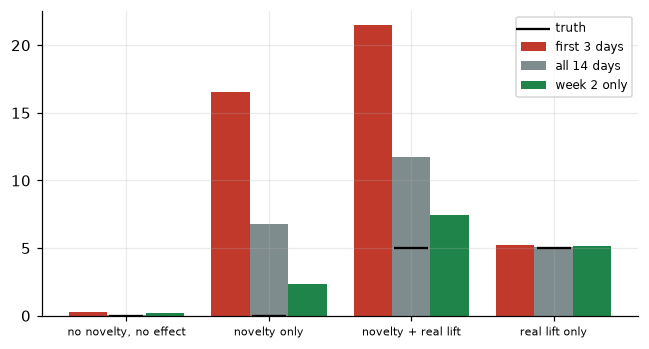

In [3]:
x = np.arange(len(nv)); fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(x - .27, nv.est_3d * 100, .27, color=BAD, label='first 3 days'); ax.bar(x, nv.est_14d * 100, .27, color=NEUTRAL, label='all 14 days'); ax.bar(x + .27, nv.est_week2 * 100, .27, color=GOOD, label='week 2 only')
ax.scatter(x, nv.true_long_run_lift * 100, marker='_', s=500, color='k', zorder=5, label='truth'); ax.set_xticks(x); ax.set_xticklabels(nv.scenario, fontsize=7); ax.legend(fontsize=8); plt.show()

## 4. Detect

Estimate the effect **per day** and fit a weighted regression of the daily effect on the day. A significantly falling trend signals novelty.

In [4]:
print('flag rate with novelty only:', nv.loc[nv.scenario == 'novelty only', 'novelty_flagged'].iloc[0].round(3))
print('false alarm rate with no novelty:', nv.loc[nv.scenario == 'no novelty, no effect', 'novelty_flagged'].iloc[0].round(3))

flag rate with novelty only: 0.408
false alarm rate with no novelty: 0.051


## 5. Fix

Run at least two full weekly cycles and report the effect from mature cohorts (here, week 2).

## 6. Verify the fix

In [5]:
print(nv[['scenario', 'true_long_run_lift', 'est_3d', 'est_14d', 'est_week2']].round(3).to_string(index=False))

             scenario  true_long_run_lift  est_3d  est_14d  est_week2
no novelty, no effect                0.00   0.003    0.001      0.002
         novelty only                0.00   0.165    0.068      0.024
  novelty + real lift                0.05   0.215    0.117      0.074
       real lift only                0.05   0.052    0.051      0.052


## So what
A test with zero long-run effect can look like a clear win after 3 days. Reading the second week recovers the truth. The trend check catches it only part of the time, so the durable fix is procedural: run long enough.